In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch

In [2]:
eventsMessi = pd.read_csv('eventsMessi.csv')

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_24620\1308467389.py:1: DtypeWarning: Columns (1,4,5,6,7,10,12,13,14,16,17,18,19,28,40,42,44,46,49,50,64,65,66,67,68,69,70,71,73,74,75,76,83,84,85,86,88,89,90,91,92,93,97,98,99,100,101,102,103,104,105,106,107,113) have mixed types. Specify dtype option on import or set low_memory=False.
  eventsMessi = pd.read_csv('eventsMessi.csv')


In [3]:
passMessi = eventsMessi[eventsMessi['type']=='Pass']

In [4]:
passMessi['pass_outcome'].unique()

array([nan, 'Incomplete', 'Out', 'Pass Offside', 'Unknown',
       'Injury Clearance'], dtype=object)

In [5]:
sPassMessi = passMessi[passMessi['pass_outcome'].isna()]

In [6]:
seasons = sorted(eventsMessi['season'].unique().tolist())

In [7]:
col = eventsMessi.columns.tolist()

initialYears = pd.DataFrame(columns=col)
pepYears = pd.DataFrame(columns=col)
msnYears = pd.DataFrame(columns=col)
swanSong = pd.DataFrame(columns=col)

dfList = []

for season in seasons:
    if(season=='2004/2005' or season=='2005/2006'
       or season=='2006/2007' or season=='2007/2008'):
        initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2008/2009' or season=='2009/2010'
       or season=='2010/2011' or season=='2011/2012'):
        pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2012/2013' or season=='2013/2014'
       or season=='2015/2016' or season=='2016/2017'):
        msnYears = pd.concat([msnYears,eventsMessi[eventsMessi['season']==season]])
    
    else:
        swanSong = pd.concat([swanSong,eventsMessi[eventsMessi['season']==season]]) 
    

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_24620\3364662301.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_24620\3364662301.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_24620\3364662301.py:21: FutureWarning: The behavior of Data

In [8]:
dfList.extend((initialYears,pepYears,msnYears,swanSong))  

In [9]:
passesIY = initialYears[initialYears['type']=='Pass']
passesPY = pepYears[pepYears['type']=='Pass']
passesMY = msnYears[msnYears['type']=='Pass']
passesSS = swanSong[swanSong['type']=='Pass']

In [10]:
sPIY = passesIY[passesIY['pass_outcome'].isna()]
sPPY = passesPY[passesPY['pass_outcome'].isna()]
sPMY = passesMY[passesMY['pass_outcome'].isna()]
sPSS = passesSS[passesSS['pass_outcome'].isna()]

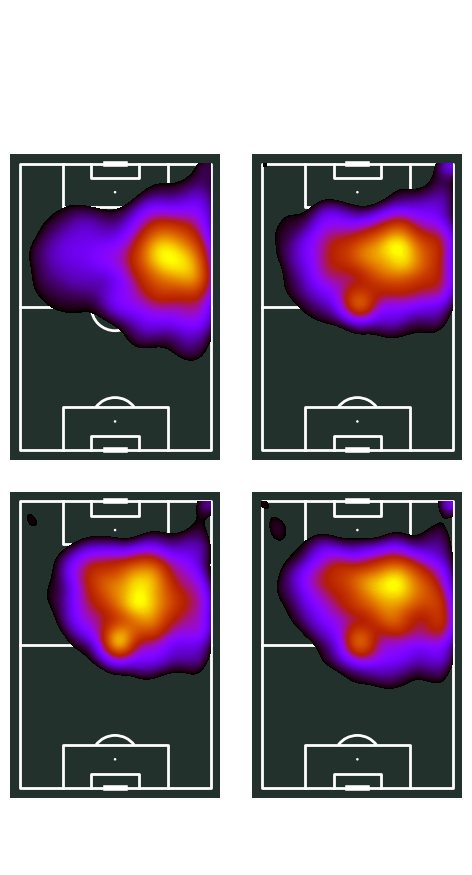

In [11]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.grid(nrows=2, ncols=2, axis=False)


kdeIY = pitch.kdeplot(sPIY['x_start'],sPIY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][0])
kdePY = pitch.kdeplot(sPPY['x_start'],sPPY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][1])
kdeMY = pitch.kdeplot(sPMY['x_start'],sPMY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][0])
kdeSS = pitch.kdeplot(sPSS['x_start'],sPSS['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][1])


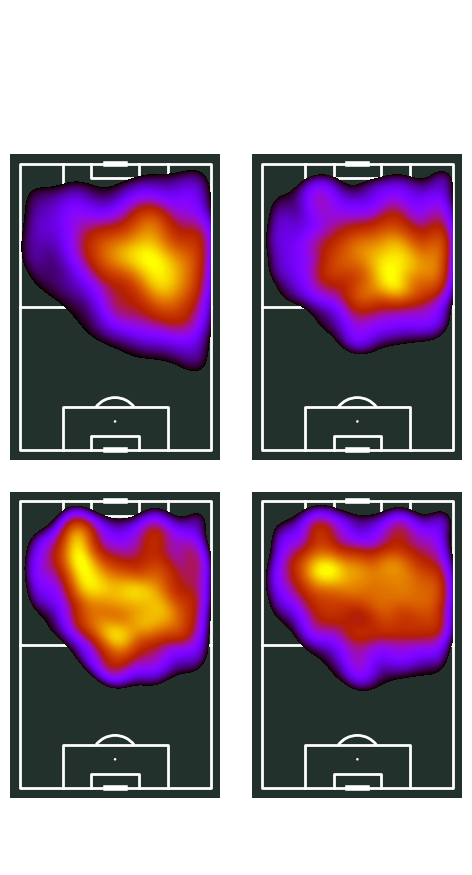

In [12]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.grid(nrows=2, ncols=2, axis=False)


kdeIY = pitch.kdeplot(sPIY['x_end'],sPIY['y_end'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][0])
kdePY = pitch.kdeplot(sPPY['x_end'],sPPY['y_end'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][1])
kdeMY = pitch.kdeplot(sPMY['x_end'],sPMY['y_end'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][0])
kdeSS = pitch.kdeplot(sPSS['x_end'],sPSS['y_end'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][1])


In [13]:
goalsIY = initialYears[initialYears['type']=='Shot']
goalsPY = pepYears[pepYears['type']=='Shot']
goalsMY = msnYears[msnYears['type']=='Shot']
goalsSS = swanSong[swanSong['type']=='Shot']

sGIY = goalsIY[goalsIY['pass_outcome'].isna()]
sGPY = goalsPY[goalsPY['pass_outcome'].isna()]
sGMY = goalsMY[goalsMY['pass_outcome'].isna()]
sGSS = goalsSS[goalsSS['pass_outcome'].isna()]

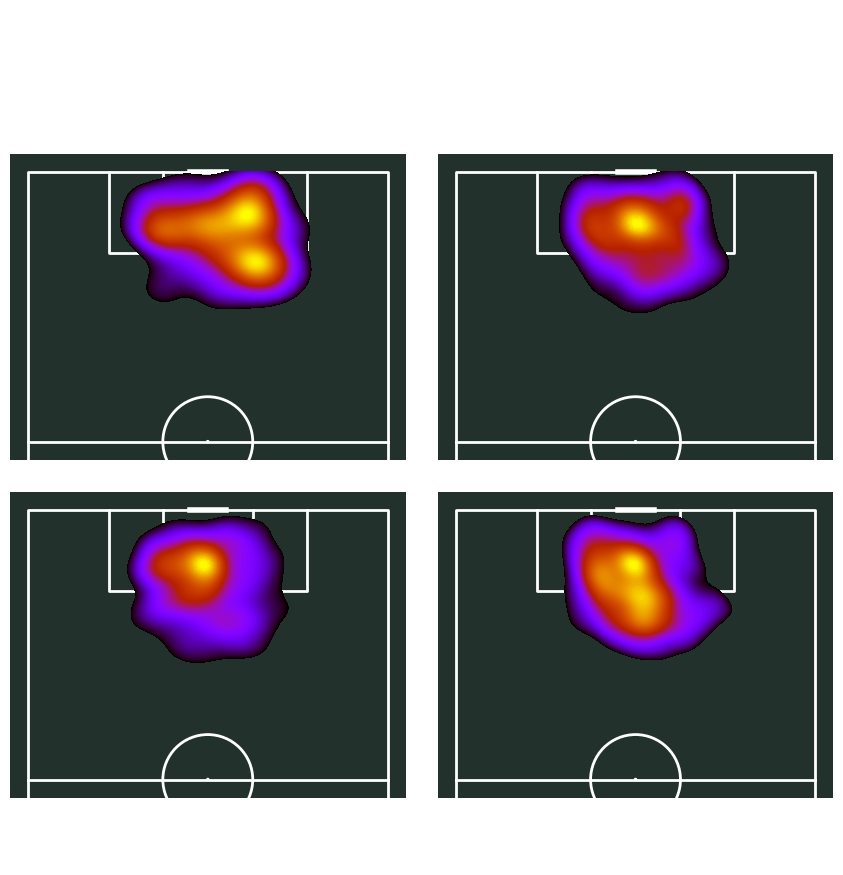

In [14]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white',half=True)
fig, ax = pitch.grid(nrows=2, ncols=2, axis=False)


kdeIY = pitch.kdeplot(sGIY['x_start'],sGIY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][0])
kdePY = pitch.kdeplot(sGPY['x_start'],sGPY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][0][1])
kdeMY = pitch.kdeplot(sGMY['x_start'],sGMY['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][0])
kdeSS = pitch.kdeplot(sGSS['x_start'],sGSS['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax['pitch'][1][1])


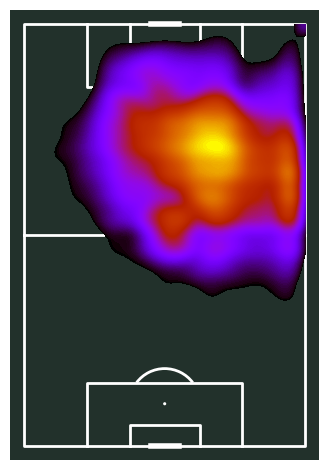

In [15]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw()

kde = pitch.kdeplot(eventsMessi['x_start'],eventsMessi['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax)

In [16]:
carries = eventsMessi[eventsMessi['type']=='Carry']

In [17]:
carries

,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,...,player_off_permanent,goalkeeper_success_out,half_end_early_video_end,goalkeeper_saved_to_post,x_start,y_start,x_end,y_end,x_carry_end,y_carry_end
5346,NaN,NaN,NaN,"[49.1, 56.9]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.2,58.1,NaN,NaN,49.1,56.9
5347,NaN,NaN,NaN,"[61.9, 34.5]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,47.7,44.6,NaN,NaN,61.9,34.5
5348,NaN,NaN,NaN,"[84.3, 59.9]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,84.2,59.5,NaN,NaN,84.3,59.9
5349,NaN,NaN,NaN,"[79.7, 59.7]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,84.3,59.9,NaN,NaN,79.7,59.7
5350,NaN,NaN,NaN,"[77.7, 58.1]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,51.4,45.2,NaN,NaN,77.7,58.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115145,NaN,NaN,NaN,"[70.3, 48.1]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,71.3,47.8,NaN,NaN,70.3,48.1
115146,NaN,NaN,NaN,"[87.1, 46.4]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,86.5,45.3,NaN,NaN,87.1,46.4
115147,NaN,NaN,NaN,"[85.0, 34.2]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,87.1,46.4,NaN,NaN,85.0,34.2
115148,NaN,NaN,NaN,"[87.7, 27.5]",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,86.1,27.3,NaN,NaN,87.7,27.5


In [19]:
carries[carries['x_carry_end']]

str

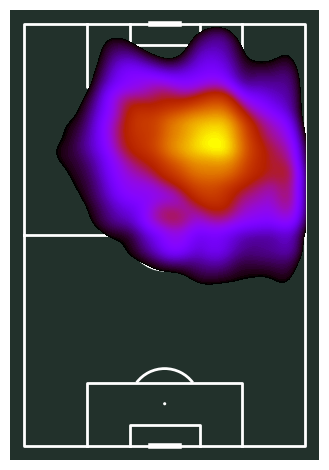

In [20]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw()

kde = pitch.kdeplot(carries['x_carry_end'],carries['y_carry_end'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax)

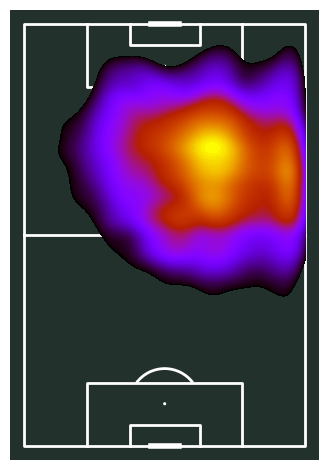

In [21]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw()

kde = pitch.kdeplot(carries['x_start'],carries['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax)

In [22]:
kde = pitch.kdeplot(carries['x_start'],carries['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax)